# Query expansion and BM25 test

This notebook builds **two expansion variants** for the goldset and runs BM25 (and RM3) retrieval tests.

**Inputs**
- Gold parquet (e.g. `output/cleaned/golden_grouped.parquet`) with columns `query`, `docs`, etc.
- dictybase_files/gene_information.txt: tab-separated table with columns GENE ID, Gene Name, Synonyms (comma-separated), Gene products. Used only for query expansion; ambiguous aliases (mapping to multiple genes) are skipped.

**Expansion rules**
- Detection: A query is expanded when it contains (1) a token matching DDB_G\d+, or (2) a token matching a gene name/synonym (case-insensitive) from the table.
- Expansion: For each detected gene we append a bounded list of aliases (gene name + synonyms). We never append gene IDs (DDB_G...) even when the gene was detected via ID.
- Two variants: query_expand_synonyms (id, gene name, synonyms only) and query_expand_long (synonyms + gene products).

**Output**: Parquet with query, query_expand_synonyms, query_expand_long, query_expand (= long), docs; flat TSV for labeling.

In [1]:
import polars as pl
import pandas as pd
import pyterrier as pt
import numpy as np

import os, math
import matplotlib.pyplot as plt
import re

In [2]:
if not pt.started():
    pt.init()

/var/folders/yr/ljjqmpj92wncw9wrv495wq300000gn/T/ipykernel_76497/3057724015.py:1: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():
Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/var/folders/yr/ljjqmpj92wncw9wrv495wq300000gn/T/ipykernel_76497/3057724015.py:2: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


# let us do one query test

In [3]:
INDEX_PATH = os.path.abspath("../indexes/dicty_bm25_index")
# INDEX_PATH = os.path.abspath("../indexes/_terrier_index_dicty_22.01.26")

# 1) load existing index from disk
index_ref = pt.IndexRef.of(INDEX_PATH)
index = pt.IndexFactory.of(index_ref)

# 2) BM25 retriever
br = pt.BatchRetrieve(index, wmodel="BM25")

/var/folders/yr/ljjqmpj92wncw9wrv495wq300000gn/T/ipykernel_76497/3826818991.py:9: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  br = pt.BatchRetrieve(index, wmodel="BM25")


In [4]:
# 3) pick one query from gold (change row index if you want)
gold = pl.read_parquet("../output/cleaned/golden_grouped.parquet")

row = gold.select(["group_claim_id", "query", "docs"]).row(100, named=True)

In [5]:
qid = str(row["group_claim_id"])
query = row["query"]
# positives = pmids from gold docs
docs = row["docs"]  # list of structs
pos_pmids = sorted({str(d.get("pmid")) for d in docs if d.get("pmid") not in (None, "", "NA")})
pos_set = set(pos_pmids)

In [6]:
print("qid:", qid)
print("query:", query)
print("n_pos_pmids:", len(pos_pmids))
print("pos_pmids (first 20):", pos_pmids[:20])

qid: 101
query: Although the IQGAP-related protein DGAP1 rgaA binds to Rac1A, it does not affect its GTPase activity.
n_pos_pmids: 2
pos_pmids (first 20): ['10825297', '9739079']


In [7]:
# 4) retrieve top K
K = 2000
qdf = pd.DataFrame([{"qid": qid, "query": query}])
res = br.transform(qdf).head(K)
res["docno"] = res["docno"].astype(str)

# 5) check where positives appear
hits = res[res["docno"].isin(pos_set)].copy().sort_values("rank")
missed = sorted(pos_set - set(res["docno"]))

print("\n--- Positive hits in top", K, "---")
print("n_hits:", len(hits), "/", len(pos_pmids))
print("best_rank:", (int(hits["rank"].min()) if len(hits) else None))
print("missed_in_topK:", len(missed))
print("missed pmids (first 20):", missed[:20])

display(hits[["qid","docno","rank","score"]].head(50))

for k in [10, 20, 50, 100, 200, 500, 1000]:
    topk = set(res[res["rank"] < k]["docno"])
    rec = len(topk & pos_set) / (len(pos_set) if len(pos_set) else 1)
    print(f"recall@{k}: {rec:.3f}")


--- Positive hits in top 2000 ---
n_hits: 2 / 2
best_rank: 1
missed_in_topK: 0
missed pmids (first 20): []


,qid,docno,rank,score
1,101,9739079,1,55.196421
3,101,10825297,3,41.753345


recall@10: 1.000
recall@20: 1.000
recall@50: 1.000
recall@100: 1.000
recall@200: 1.000
recall@500: 1.000
recall@1000: 1.000


In [8]:
# # check the abstract
# gid = gold.select("group_claim_id").row(0)[0]   # scalar int
# # or: gid = gold.get_column("group_claim_id")[0]

# pos_docs = (
#     gold
#     .filter(pl.col("group_claim_id") == gid)
#     .select(["group_claim_id", "query", "docs"])
#     .explode("docs")
#     .with_columns([
#         pl.col("docs").struct.field("pmid").alias("pmid"),
#         pl.col("docs").struct.field("publication_id").alias("publication_id"),
#         pl.col("docs").struct.field("title").alias("title"),
#         pl.col("docs").struct.field("abstract_clean").alias("abstract_clean"),
#         pl.col("docs").struct.field("year").alias("year"),
#     ])
#     .drop("docs")
# )

# with pl.Config(fmt_str_lengths=10_000, tbl_rows=200, tbl_cols=20):
#     display(pos_docs)

In this first row, BM25 gives the citation at rank 0, so perfectly matched

# let us prepare the results for gold and BM25

In [9]:
# -------------------------
# build mappings for gold
# -------------------------

# qid -> query
queries_df = gold.select([
    pl.col("group_claim_id").cast(pl.Utf8).alias("qid"),
    pl.col("query").alias("query"),
])

# qid -> set(pmids)
gold_pmids = (
    gold.select(["group_claim_id", "docs"])
        .explode("docs")
        .with_columns([
            pl.col("group_claim_id").cast(pl.Utf8).alias("qid"),
            pl.col("docs").struct.field("pmid").cast(pl.Utf8).alias("pmid"),
        ])
        .filter(pl.col("pmid").is_not_null() & (pl.col("pmid") != "") & (pl.col("pmid") != "NA"))
        .select(["qid", "pmid"])
        .unique()
)

gold_map: dict[str, set[str]] = {}
for qid, pmid in gold_pmids.iter_rows():
    gold_map.setdefault(qid, set()).add(pmid)

In [10]:
# -------------------------
# Run retrieval (overfetch)
# -------------------------
qdf = queries_df.to_pandas()

K_MAX = 500
res_all = br.transform(qdf)

res = (
    res_all
    .sort_values(["qid", "rank"], ascending=[True, True])
    .groupby("qid", as_index=False)
    .head(K_MAX)
)
res["qid"] = res["qid"].astype(str)
res["docno"] = res["docno"].astype(str)
res = res.sort_values(["qid", "rank"], ascending=[True, True])

# Build run_map: qid -> ranked list (docno)
run_map: dict[str, list[str]] = {}
for qid, grp in res.groupby("qid", sort=False):
    run_map[qid] = grp["docno"].tolist()

In [11]:
res_all.shape, res.shape

((1702921, 6), (851901, 6))

In [12]:
len(run_map)

1705

# let us implement the eval strategy from BIOASQ

In [13]:
# -------------------------
# BioASQ-style AP + extras
# -------------------------
def ap_bioasq(ranked: list[str], relset: set[str], k: int = 10) -> float:
    """
    AP with denominator min(|relset|, k), matching BioASQ Phase A doc AP behavior.
    """
    ranked = ranked[:k]
    if not relset:
        return 0.0
    denom = min(len(relset), k)
    if denom == 0:
        return 0.0
    hits = 0
    s = 0.0
    for i, docno in enumerate(ranked, start=1):
        if docno in relset:
            hits += 1
            s += hits / i
    return s / denom

def rr_at_k(ranked: list[str], relset: set[str], k: int = 10) -> float:
    ranked = ranked[:k]
    for i, docno in enumerate(ranked, start=1):
        if docno in relset:
            return 1.0 / i
    return 0.0

def success_at_k(ranked: list[str], relset: set[str], k: int = 10) -> int:
    ranked = ranked[:k]
    return int(any(docno in relset for docno in ranked))

def recall_at_k(ranked: list[str], relset: set[str], k: int) -> float:
    ranked = ranked[:k]
    if not relset:
        return 0.0
    return len(set(ranked) & relset) / len(relset)

In [14]:
# -------------------------
# Evaluate baseline BM25
# -------------------------
Ks_recall = [50, 100, 200, 500]
eps_power = 5   # matches BioASQ -e 5 (epsilon = 1e-5)
eps = 10 ** (-eps_power)

def evaluate_run(gold_map: dict[str, set[str]], run_map: dict[str, list[str]], k_max: int, ks_recall: list[int] = None) -> tuple[dict, pl.DataFrame]:
    """Generic evaluation function for any run_map against gold_map"""
    if ks_recall is None:
        ks_recall = [50, 100, 200, 500]
    
    perq = []
    APs, RRs, S10s = [], [], []
    recalls = {K: [] for K in ks_recall}

    for qid, relset in gold_map.items():
        ranked = run_map.get(qid, [])

        ap = ap_bioasq(ranked, relset, k=10)
        rr = rr_at_k(ranked, relset, k=10)
        s10 = success_at_k(ranked, relset, k=10)

        APs.append(ap)
        RRs.append(rr)
        S10s.append(s10)

        rec_k_vals = {}
        for K in ks_recall:
            rK = recall_at_k(ranked, relset, k=K)
            recalls[K].append(rK)
            rec_k_vals[f"recall@{K}"] = rK

        perq.append({
            "qid": qid,
            "n_gold": len(relset),
            "AP@10": ap,
            "RR@10": rr,
            "Success@10": s10,
            **rec_k_vals,
        })

    MAP10 = sum(APs) / len(APs) if APs else 0.0
    GMAP10 = math.exp(sum(math.log(a + eps) for a in APs) / len(APs)) if APs else 0.0
    MRR10 = sum(RRs) / len(RRs) if RRs else 0.0
    Success10 = sum(S10s) / len(S10s) if S10s else 0.0
    RecallK = {K: (sum(vals) / len(vals) if vals else 0.0) for K, vals in recalls.items()}

    summary = {
        "MRR@10": MRR10,
        "Success@10": Success10,
        "MAP@10": MAP10,
        "GMAP@10": GMAP10,
        **{f"Recall@{K}": RecallK[K] for K in ks_recall},
        "n_queries": len(gold_map),
        "K_MAX_retrieved": k_max,
    }
    
    perq_df = pl.DataFrame(perq).sort("RR@10")
    return summary, perq_df

def run_retrieval(retriever, qdf: pd.DataFrame, k_max: int) -> dict[str, list[str]]:
    """Run retrieval and build run_map: qid -> ranked docno list"""
    res_all = retriever.transform(qdf)
    res = (
        res_all
        .sort_values(["qid", "rank"], ascending=[True, True])
        .groupby("qid", as_index=False)
        .head(k_max)
    )
    res["qid"] = res["qid"].astype(str)
    res["docno"] = res["docno"].astype(str)
    
    run_map = {}
    for qid, grp in res.groupby("qid", sort=False):
        run_map[qid] = grp["docno"].tolist()
    return run_map

summary, perq_df = evaluate_run(gold_map, run_map, K_MAX, Ks_recall)
print(summary)
perq_df

{'MRR@10': 0.5979265000232742, 'Success@10': 0.750733137829912, 'MAP@10': 0.5596210724759112, 'GMAP@10': 0.0398330833949438, 'Recall@50': 0.8101275427081879, 'Recall@100': 0.8507880649816134, 'Recall@200': 0.8793697342084439, 'Recall@500': 0.9118614718614718, 'n_queries': 1705, 'K_MAX_retrieved': 500}


qid,n_gold,AP@10,RR@10,Success@10,recall@50,recall@100,recall@200,recall@500
str,i64,f64,f64,i64,f64,f64,f64,f64
"""734""",1,0.0,0.0,0,0.0,0.0,0.0,0.0
"""870""",1,0.0,0.0,0,1.0,1.0,1.0,1.0
"""362""",1,0.0,0.0,0,0.0,0.0,0.0,0.0
"""777""",1,0.0,0.0,0,1.0,1.0,1.0,1.0
"""67""",1,0.0,0.0,0,1.0,1.0,1.0,1.0
…,…,…,…,…,…,…,…,…
"""1084""",1,1.0,1.0,1,1.0,1.0,1.0,1.0
"""1590""",1,1.0,1.0,1,1.0,1.0,1.0,1.0
"""1457""",1,1.0,1.0,1,1.0,1.0,1.0,1.0


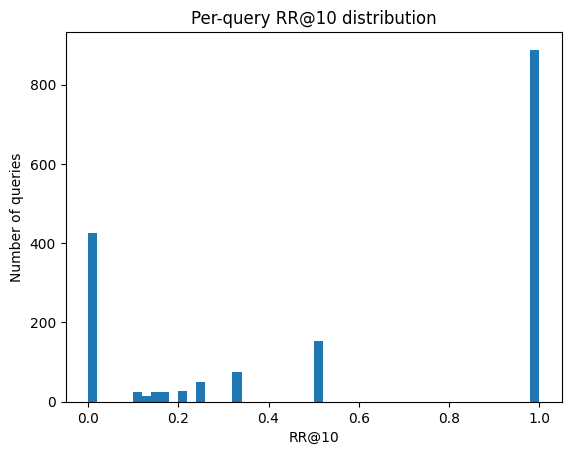

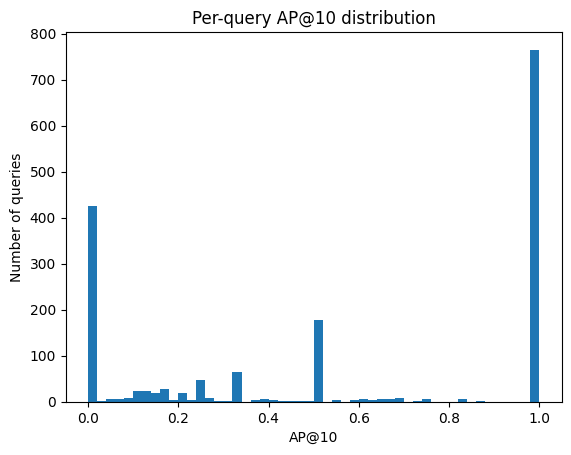

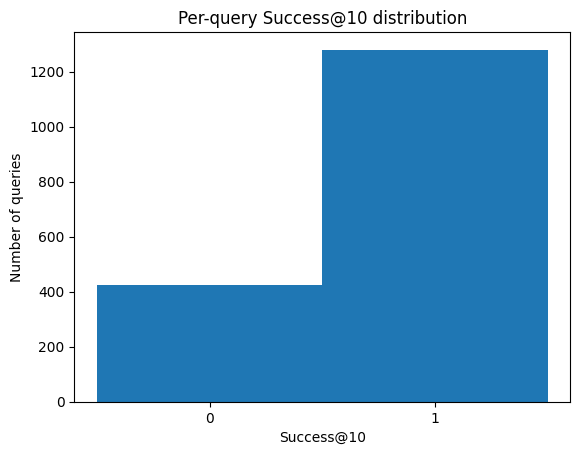

In [15]:
# perq_df: Polars DataFrame from evaluation (columns: "RR@10","AP@10","Success@10","recall@50"...)
# summary: dict from evaluation (keys: "MRR@10", "Recall@50", ...)

pdf = perq_df.to_pandas()

# 1) RR@10 distribution
plt.figure()
plt.hist(pdf["RR@10"], bins=50)
plt.title("Per-query RR@10 distribution")
plt.xlabel("RR@10")
plt.ylabel("Number of queries")
plt.show()

# 2) AP@10 distribution
plt.figure()
plt.hist(pdf["AP@10"], bins=50)
plt.title("Per-query AP@10 distribution")
plt.xlabel("AP@10")
plt.ylabel("Number of queries")
plt.show()

# 3) Success@10 distribution (0/1)
plt.figure()
plt.hist(pdf["Success@10"], bins=[-0.5, 0.5, 1.5])
plt.title("Per-query Success@10 distribution")
plt.xlabel("Success@10")
plt.ylabel("Number of queries")
plt.xticks([0, 1])
plt.show()

this can be seen as a baseline result. looks OK

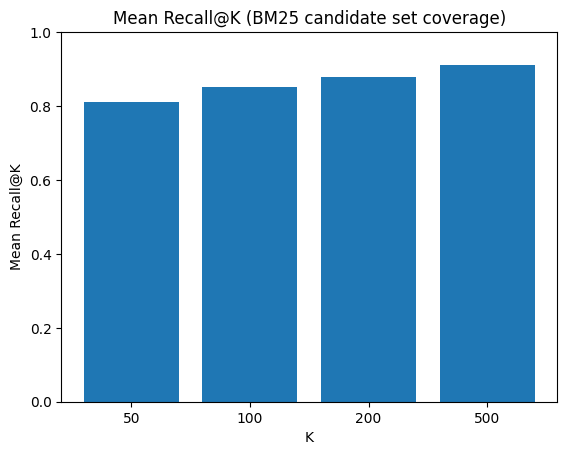

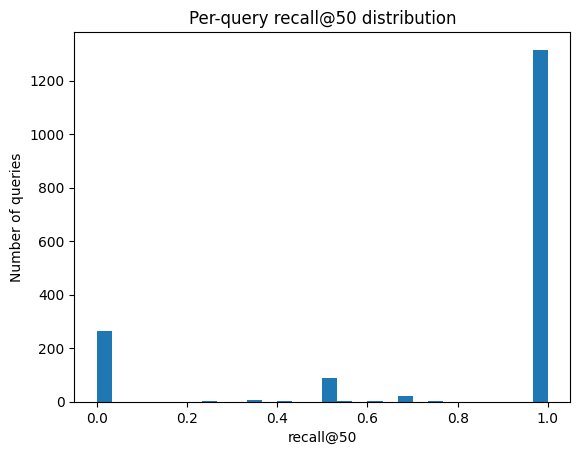

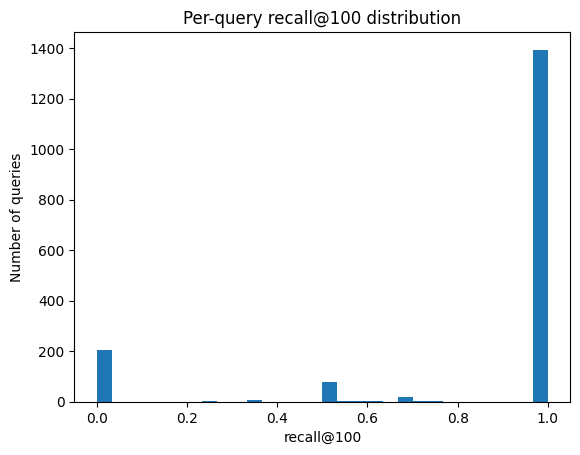

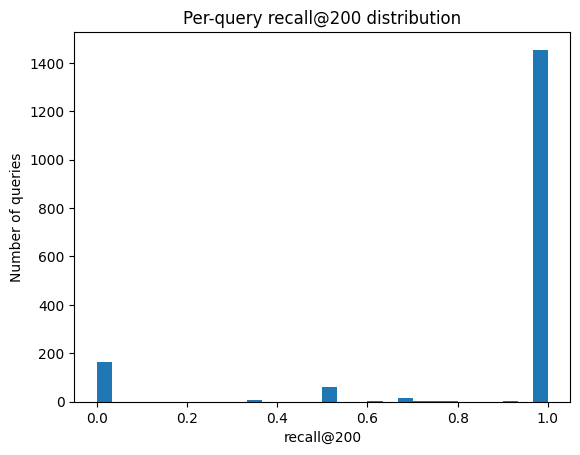

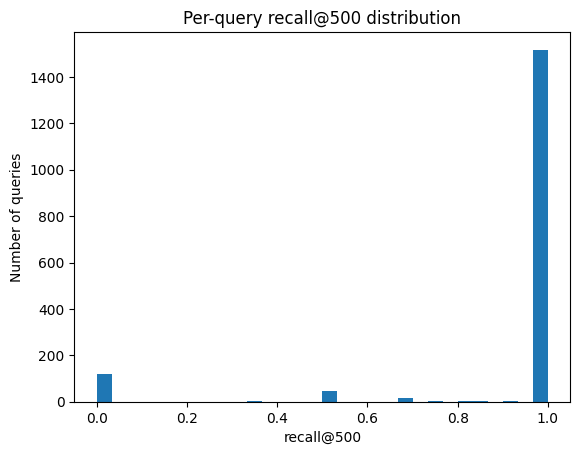

In [16]:
# 4) Mean Recall@K bar chart
Ks = [50, 100, 200, 500]
rec_vals = [summary.get(f"Recall@{k}", 0.0) for k in Ks]

plt.figure()
plt.bar([str(k) for k in Ks], rec_vals)
plt.title("Mean Recall@K (BM25 candidate set coverage)")
plt.xlabel("K")
plt.ylabel("Mean Recall@K")
plt.ylim(0, 1)
plt.show()

# 5) Optional: per-query Recall@K distributions
for k in Ks:
    col = f"recall@{k}"
    if col in pdf.columns:
        plt.figure()
        plt.hist(pdf[col], bins=30)
        plt.title(f"Per-query {col} distribution")
        plt.xlabel(col)
        plt.ylabel("Number of queries")
        plt.ylim(bottom=0)
        plt.show()

In [17]:
# qids where BM25 retrieved none of the gold docs in top 500
zero_qids = (
    perq_df
    .filter(pl.col("recall@500") == 0)
    .select(pl.col("qid").cast(pl.Utf8))
)

# Pull query + gold docs for those qids
zero_cases = (
    gold
    .with_columns(pl.col("group_claim_id").cast(pl.Utf8).alias("qid"))
    .join(zero_qids, on="qid", how="inner")
    .select(["qid", "query", "docs", "n_citations", "n_variants"])
    .explode("docs")
    .with_columns([
        pl.col("docs").struct.field("pmid").alias("pmid"),
        pl.col("docs").struct.field("publication_id").alias("publication_id"),
        pl.col("docs").struct.field("title").alias("title"),
        pl.col("docs").struct.field("abstract_clean").alias("abstract_clean"),
        pl.col("docs").struct.field("year").alias("year"),
    ])
    .drop("docs")
    .sort(["qid", "pmid"])
)

# with pl.Config(fmt_str_lengths=10_000, tbl_rows=5000, tbl_cols=30):
#     display(zero_cases)
zero_cases

qid,query,n_citations,n_variants,pmid,publication_id,title,abstract_clean,year
str,str,u32,u32,str,i64,str,str,i32
"""1002""","""pirA /AX2 null cells also have…",1,1,"""28889942""",16764,"""Differential functions of WAVE…","""The WAVE regulatory complex (W…",2017
"""1005""","""PKA is also part of the signal…",1,1,"""9584128""",3792,"""YakA, a protein kinase require…","""When Dictyostelium cells starv…",1998
"""1057""","""rab7A is expressed at a relati…",1,2,"""9243512""",4031,"""Evidence for a recycling role …","""The mammalian small molecular …",1997
"""1059""","""rab32A is expressed at very lo…",1,1,"""10025509""",3202,"""Molecular characterization of …","""The superfamily of small GTPas…",1999
"""109""","""An analysis of Dictyostelium r…",1,6,"""29614268""",17329,"""Loss of RapC causes defects in…","""The small GTPase Ras proteins …",2018
…,…,…,…,…,…,…,…,…
"""961""","""Over-expression of pdeE leads …",1,1,"""12429832""",2105,"""Identification and characteriz…","""Recently, we recognized two ge…",2002
"""979""","""pdeE is expressed between 6 an…",1,1,"""25887420""",14621,"""Leaps and lulls in the develop…","""Background Development of the …",2015
"""982""","""PefBhas been shown to localize…",2,2,"""11481037""",2415,"""Identification and characteriz…","""Penta-EF-hand (PEF) proteins s…",2001


In [18]:
with pl.Config(fmt_str_lengths=10_000, tbl_rows=5, tbl_cols=30):
    display(zero_cases)

qid,query,n_citations,n_variants,pmid,publication_id,title,abstract_clean,year
str,str,u32,u32,str,i64,str,str,i32
"""1002""","""pirA /AX2 null cells also have defects in cytokinesis and cell motility.""",1,1,"""28889942""",16764,"""Differential functions of WAVE regulatory complex subunits in the regulation of actin-driven processes.""","""The WAVE regulatory complex (WRC) links upstream Rho-family GTPase signaling to the activation of the ARP2/3 complex in different organisms. WRC-induced and ARP2/3 complex-mediated actin nucleation beneath the plasma membrane is critical for actin assembly in the leading edge to drive efficient cell migration. The WRC is a stable heteropentamer composed of SCAR/WAVE, Abi, Nap, Pir and the small polypeptide Brk1/Hspc300. Functional interference with individual subunits of the complex frequently results in diminished amounts of the remaining polypeptides of the WRC complex, implying the complex to act as molecular entity. However, Abi was also found to associate with mammalian N-WASP, formins, Eps8/SOS1 or VASP, indicating additional functions of individual WRC subunits in eukaryotic cells. To address this issue systematically, we inactivated all WRC subunits, either alone or in combination with VASP in Dictyostelium cells and quantified the protein content of the remaining subunits in respective WRC knockouts. The individual mutants displayed highly differential phenotypes concerning various parameters, including cell morphology, motility, cytokinesis or multicellular development, corroborating the view of additional roles for individual subunits, beyond their established function in WRC-mediated Arp2/3 complex activation. Finally, our data uncover the interaction of the actin polymerase VASP with WRC-embedded Abi to mediate VASP accumulation in cell protrusions, driving efficient cell migration.""",2017
"""1005""","""PKA is also part of the signal transduction pathway by which Prestarvation Factor PSF stimulates expression of carA carA-1, carA-2 and acaA at the initiation of development.""",1,1,"""9584128""",3792,"""YakA, a protein kinase required for the transition from growth to development in Dictyostelium.""","""When Dictyostelium cells starve they arrest their growth and induce the expression of genes necessary for development. We have identified and characterized a protein kinase, YakA, that is essential for the proper regulation of both events. Amino acid sequence and functional similarities indicate that YakA is a homolog of Yak1p, a growth-regulating protein kinase in S. cerevisiae. Purified YakA expressed in E. coli is able to phosphorylate myelin basic protein. YakA-null cells are smaller and their cell cycle is accelerated relative to wild-type cells. When starved, YakA-null cells fail to decrease the expression of the growth-stage gene cprD, and do not induce the expression of genes required for the earliest stages of development. YakA mRNA levels increase during exponential growth and reach a maximum at the point of starvation, consistent with a role in mediating starvation responses. YakA mRNA also accumulates when cells are grown in medium conditioned by cells grown to high density, suggesting that yakA expression is under the control of an extracellular signal that accumulates during growth. Expression of yakA from a conditional promoter causes cell-cycle arrest in nutrient-rich medium and promotes developmental events, such as the expression of genes required for cAMP signaling. YakA appears to regulate the transition from growth to development in Dictyostelium.""",1998
"""1057""","""rab7A is expressed at a relatively high level throughout both growth and development.""",1,2,"""9243512""",4031,"""Evidence for a recycling role for Rab7 in regulating a late step in endocytosis and in retention of lysosomal enzymes in Dictyostelium discoideum.""","""The mammalian small molecular weight GTPase Rab7 (Ypt7 in yeast) has been implicated in regulating membrane traffic at postinter

In [19]:
zero_cases.write_csv("../output/cleaned/golden_zero_recall500_to_inspect.tsv", separator="\t")

just from looking at this, it seems 0 at recall@500 is because this claims are summarized from text not abstract. so missing them is as expected

# tune K1 and b

In [20]:
# -----------------------------
# Settings
# -----------------------------
K_CAND = 200          # retrieval depth for reranker candidate set
K_RR = 10             # MRR@10
DEV_FRAC = 0.8        # fraction split dev/test
SEED = 1

# Grid (feel free to edit)
k1_list = [0.6, 0.9, 1.2, 1.5, 2.0]
b_list  = [0.3, 0.6, 0.75, 0.9]

In [21]:
# -----------------------------
# Split dev/test by qid
# -----------------------------
# queries_df is your Polars DF with columns: qid, query
qids_all = queries_df.select(pl.col("qid").cast(pl.Utf8)).get_column("qid").to_list()

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(qids_all))
cut = int(len(qids_all) * DEV_FRAC)

dev_qids = set([qids_all[i] for i in perm[:cut]])
test_qids = set([qids_all[i] for i in perm[cut:]])

dev_topics = queries_df.filter(pl.col("qid").is_in(list(dev_qids))).to_pandas()
test_topics = queries_df.filter(pl.col("qid").is_in(list(test_qids))).to_pandas()

dev_gold = {qid: gold_map[qid] for qid in dev_qids if qid in gold_map}
test_gold = {qid: gold_map[qid] for qid in test_qids if qid in gold_map}

print("n_all:", len(qids_all), "n_dev:", len(dev_gold), "n_test:", len(test_gold))

n_all: 1705 n_dev: 1364 n_test: 341


In [22]:
# -------------------------
# Helpers for grid search
# Note: rr_at_k, recall_at_k, ap_bioasq, success_at_k already defined earlier
# -------------------------
def eval_run(gold_map: dict[str, set[str]], run_map: dict[str, list[str]], k_rr: int = 10, k_rec: int = 200):
    """Quick eval for grid search: returns only MRR@k_rr and Recall@k_rec"""
    qids = list(gold_map.keys())
    rrs = []
    recs = []
    for qid in qids:
        ranked = run_map.get(qid, [])
        relset = gold_map[qid]
        rrs.append(rr_at_k(ranked, relset, k=k_rr))
        recs.append(recall_at_k(ranked, relset, k=k_rec))
    return {
        "MRR@10": float(np.mean(rrs)) if rrs else 0.0,
        f"Recall@{k_rec}": float(np.mean(recs)) if recs else 0.0,
    }

def run_bm25(index, topics_pd: pd.DataFrame, k1: float, b: float, K: int = 200) -> dict[str, list[str]]:
    """Run BM25 with custom k1, b parameters (for grid search)"""
    rtr = pt.terrier.Retriever(
        index,
        wmodel="BM25",
        controls={"bm25.k_1": k1, "bm25.b": b},
        num_results=K
    )
    return run_retrieval(rtr, topics_pd, K)

In [23]:
# -----------------------------
# Grid search
# -----------------------------
rows = []

for k1 in k1_list:
    for b in b_list:
        run_dev = run_bm25(index, dev_topics, k1=k1, b=b, K=K_CAND)
        dev_metrics = eval_run(dev_gold, run_dev, k_rr=K_RR, k_rec=K_CAND)

        run_test = run_bm25(index, test_topics, k1=k1, b=b, K=K_CAND)
        test_metrics = eval_run(test_gold, run_test, k_rr=K_RR, k_rec=K_CAND)

        # Pick a dev selection criterion: prioritize Recall@200, tie-break by MRR@10
        dev_score = dev_metrics[f"Recall@{K_CAND}"] + 0.1 * dev_metrics["MRR@10"]  # <-------- this can need a second thought

        rows.append({
            "k1": k1,
            "b": b,
            "dev_Recall@200": dev_metrics[f"Recall@{K_CAND}"],
            "dev_MRR@10": dev_metrics["MRR@10"],
            "dev_score": dev_score,
            "test_Recall@200": test_metrics[f"Recall@{K_CAND}"],
            "test_MRR@10": test_metrics["MRR@10"],
        })

results = pl.DataFrame(rows).sort("dev_score", descending=True)

with pl.Config(tbl_rows=200, tbl_cols=20):
    display(results)

best = results.row(0, named=True)
print("\nBEST (by dev_score):", best)



k1,b,dev_Recall@200,dev_MRR@10,dev_score,test_Recall@200,test_MRR@10
f64,f64,f64,f64,f64,f64,f64
0.9,0.9,0.88851,0.600234,0.948533,0.846474,0.589054
0.9,0.75,0.88741,0.602206,0.947631,0.846474,0.595514
1.2,0.75,0.88741,0.600062,0.947417,0.847207,0.589383
1.2,0.9,0.88741,0.598888,0.947299,0.846474,0.591242
0.9,0.6,0.887044,0.601006,0.947144,0.846474,0.595878
0.6,0.9,0.886799,0.600458,0.946845,0.846718,0.58466
1.5,0.9,0.887044,0.594809,0.946525,0.846474,0.583845
1.2,0.6,0.885944,0.599933,0.945937,0.847207,0.590206
0.9,0.3,0.886066,0.597489,0.945815,0.849407,0.583375



BEST (by dev_score): {'k1': 0.9, 'b': 0.9, 'dev_Recall@200': 0.888510101010101, 'dev_MRR@10': 0.6002339058790672, 'dev_score': 0.9485334915980077, 'test_Recall@200': 0.8464739561513756, 'test_MRR@10': 0.5890541358283293}


In [24]:
# save results (optional)
# results.write_csv("../tmp/bm25_gridsearch_devtest.tsv", separator="\t")

Tune parameters change results unsignificant. Default BM25 (k1=1.2, b=0.75))for the baseline report.

Dev: Recall@200 = 0.886311, MRR@10 = 0.601671

Test: Recall@200 = 0.850140, MRR@10 = 0.589982

Better choices for scoring function:
pick highest Recall@200
tie-break by MRR@10

# look into zero_cases of recall@500
there are several options for the next step but let us do more research on zero_cases

In [25]:
zeros = (
    perq_df.filter(pl.col("recall@500") == 0)
           .select("qid")
           .to_series()
           .to_list()
)

ones = (
    perq_df.filter(pl.col("recall@500") == 1)
           .select("qid")
           .to_series()
           .to_list()
)

print("n recall@500==0:", len(zeros))
print("n recall@500==1:", len(ones))

n recall@500==0: 121
n recall@500==1: 1517


In [26]:
def show_gold_docs(gold: pl.DataFrame, qid: str):
    g = (
        gold.filter(pl.col("group_claim_id").cast(pl.Utf8) == str(qid))
            .select(["group_claim_id", "query", "docs"])
            .explode("docs")
            .with_columns([
                pl.col("docs").struct.field("pmid").alias("pmid"),
                pl.col("docs").struct.field("title").alias("title"),
                pl.col("docs").struct.field("abstract_clean").alias("abstract_clean"),
                pl.col("docs").struct.field("year").alias("year"),
            ])
            .drop("docs")
    )
    with pl.Config(fmt_str_lengths=10_000, tbl_rows=200, tbl_cols=20):
        display(g)



In [27]:

def inspect_query(res: pd.DataFrame, gold_map: dict[str, set[str]], gold: pl.DataFrame, qid: str, top_show: int = 20):
    qid = str(qid)
    rel = gold_map.get(qid, set())

    # show query text
    qtxt = gold.filter(pl.col("group_claim_id").cast(pl.Utf8) == qid).select("query").row(0)[0]
    print("\n==============================")
    print("QID:", qid)
    print("QUERY:", qtxt)
    print("N gold pmids:", len(rel))

    # show gold docs
    print("\n--- GOLD DOCS (title/abstract) ---")
    show_gold_docs(gold, qid)

    # get retrieved ranking
    r = res[res["qid"].astype(str) == qid].sort_values("rank").copy()
    r["docno"] = r["docno"].astype(str)

    # compute first relevant rank + hits
    hits = r[r["docno"].isin(rel)].copy().sort_values("rank")
    first_rank = int(hits["rank"].iloc[0]) if len(hits) else None

    print("\n--- BM25 TOP", top_show, "---")
    display(r.head(top_show)[["qid", "docno", "rank", "score"]])

    print("\n--- POSITIVES FOUND IN TOP500 ---")
    print("n_hits:", len(hits), "/", len(rel))
    print("first_relevant_rank:", first_rank)
    if len(hits):
        display(hits.head(50)[["qid", "docno", "rank", "score"]])

In [28]:
# pick a few examples
for qid in zeros[:5]:
    inspect_query(res, gold_map, gold, qid, top_show=10)


QID: 734
QUERY: In I6KA null cells, there is an increased localization of CRAC dagA to the plasma membrane compared with wt.
N gold pmids: 1

--- GOLD DOCS (title/abstract) ---


group_claim_id,query,pmid,title,abstract_clean,year
i64,str,str,str,str,i32
734,"""In I6KA null cells, there is an increased localization of CRAC dagA to the plasma membrane compared with wt.""","""13678580""","""Inositol pyrophosphates mediate chemotaxis in Dictyostelium via pleckstrin homology domain-PtdIns(3,4,5)P3 interactions.""","""Inositol phosphates are well-known signaling molecules, whereas the inositol pyrophosphates, such as diphosphoinositol pentakisphosphate (InsP7/IP7) and bis-diphosphoinositol tetrakisphosphate (InsP8/IP8), are less well characterized. We demonstrate physiologic regulation of Dictyostelium chemotaxis by InsP7 mediated by its competition with PtdIns(3,4,5)P3 for binding pleckstrin homology (PH) domain-containing proteins. Chemoattractant stimulation triggers rapid and sustained elevations in InsP7/InsP8 levels. Depletion of InsP7 and InsP8 by deleting the gene for InsP6 kinase (InsP6K/IP6K), which converts inositol hexakisphosphate (InsP6/IP6) to InsP7, causes rapid aggregation of mutant cells and increased sensitivity to cAMP. Chemotaxis is mediated by membrane translocation of certain PH domain-containing proteins via specific binding to PtdIns(3,4,5)P3. InsP7 competes for PH domain binding with PtdIns(3,4,5)P3 both in vitro and in vivo. InsP7 depletion enhances PH domain membrane translocation and augments downstream chemotactic signaling activity.""",2003



--- BM25 TOP 10 ---


,qid,docno,rank,score
732298,734,8089184,0,40.012727
732299,734,8188693,1,31.718637
732300,734,11274054,2,30.436265
732301,734,17898079,3,29.174214
732302,734,10075837,4,28.163975
732303,734,36017702,5,26.333027
732304,734,12686622,6,25.338242
732305,734,8536802,7,23.420934
732306,734,21334306,8,23.152549
732307,734,8702473,9,22.255873



--- POSITIVES FOUND IN TOP500 ---
n_hits: 0 / 1
first_relevant_rank: None

QID: 362
QUERY: dlpA is expressed in pre-stalk cells.
N gold pmids: 1

--- GOLD DOCS (title/abstract) ---


...


--- POSITIVES FOUND IN TOP500 ---
n_hits: 0 / 1
first_relevant_rank: None

QID: 795
QUERY: It is found associated with vacuole membrane protein 1 vmp1 on specialized regions of the endoplasmic reticulum ER enriched in phosphatidylinositol-3-P PtdIns3P that give rise to autophagosomes.
N gold pmids: 1

--- GOLD DOCS (title/abstract) ---


group_claim_id,query,pmid,title,abstract_clean,year
i64,str,str,str,str,i32
795,"""It is found associated with vacuole membrane protein 1 vmp1 on specialized regions of the endoplasmic reticulum ER enriched in phosphatidylinositol-3-P PtdIns3P that give rise to autophagosomes.""","""22024750""","""The induction of autophagy by mechanical stress.""","""The ability to respond and adapt to changes in the physical environment is a universal and essential cellular property. Here we demonstrated that cells respond to mechanical compressive stress by rapidly inducing autophagosome formation. We measured this response in both Dictyostelium and mammalian cells, indicating that this is an evolutionarily conserved, general response to mechanical stress. In Dictyostelium, the number of autophagosomes increased 20-fold within 10 min of 1 kPa pressure being applied and a similar response was seen in mammalian cells after 30 min. We showed in both cell types that autophagy is highly sensitive to changes in mechanical pressure and the response is graduated, with half-maximal responses at ~0.2 kPa, similar to other mechano-sensitive responses. We further showed that the mechanical induction of autophagy is TOR-independent and transient, lasting until the cells adapt to their new environment and recover their shape. The autophagic response is therefore part of an integrated response to mechanical challenge, allowing cells to cope with a continuously changing physical environment.""",2011



--- BM25 TOP 10 ---


,qid,docno,rank,score
793298,795,25131297,0,103.846606
793299,795,32296305,1,64.426866
793300,795,18641456,2,63.193778
793301,795,27861594,3,62.946374
793302,795,35044051,4,62.140500
793303,795,34709991,5,60.599115
793304,795,20009561,6,60.037770
793305,795,34328055,7,57.950111
793306,795,20980813,8,56.380725
793307,795,18550798,9,51.135202



--- POSITIVES FOUND IN TOP500 ---
n_hits: 0 / 1
first_relevant_rank: None


In [29]:
for qid in ones[:3]:
    inspect_query(res, gold_map, gold, qid, top_show=5)


QID: 870
QUERY: mRNA levels of racI increase during sexual development, suggesting that racI may function in sexual development.
N gold pmids: 1

--- GOLD DOCS (title/abstract) ---


group_claim_id,query,pmid,title,abstract_clean,year
i64,str,str,str,str,i32
870,"""mRNA levels of racI increase during sexual development, suggesting that racI may function in sexual development.""","""16573737""","""Small GTPase RacF2 affects sexual cell fusion and asexual development in Dictyostelium discoideum through the regulation of cell adhesion.""","""Cells of Dictyostelium discoideum become sexually mature when submerged and in darkness, and fuse with opposite mating-type cells as gametes. The gene for a Rho GTPase, RacF2, is one of the extremely gamete-enriched genes (>100-fold) identified by us previously. Here, we isolated knockout, overexpression, constitutively active and dominant negative mutants of RacF2, and analyzed their phenotypes. These mutants showed anomalies in the extent of sexual cell fusion and asexual development as well as in EDTA-sensitive cell-cell adhesion. It is suggested that RacF2 controls the process of sexual and asexual development through the regulation of cellular adhesiveness. An analysis of the expression of all 18 rac family genes by real-time polymerase chain reaction revealed that four additional genes, rac1b, rac1c, racF1 and racG, were induced during maturation, suggesting their possible involvement in sexual cell interactions.""",2006



--- BM25 TOP 5 ---


,qid,docno,rank,score
868298,870,11201251,0,26.509093
868299,870,37282112,1,17.989848
868300,870,8086285,2,17.036943
868301,870,8482335,3,16.948843
868302,870,9108336,4,16.865803



--- POSITIVES FOUND IN TOP500 ---
n_hits: 1 / 1
first_relevant_rank: 19


...

group_claim_id,query,pmid,title,abstract_clean,year
i64,str,str,str,str,i32
67,"""Additionally, in situ hybridization analysis of pefA shows expression in the posterior presporeregion.""","""11481037""","""Identification and characterization of two penta-EF-hand Ca(2+)-binding proteins in Dictyostelium discoideum.""","""Penta-EF-hand (PEF) proteins such as ALG-2 (apoptosis-linked gene 2 product) and the calpain small subunit are a newly classified family of Ca(2+)-binding proteins that possess five EF-hand-like motifs. We identified two mutually homologous PEF proteins, designated DdPEF-1 and DdPEF-2 (64% amino acid residue identities), in the cellular slime mold Dictyostelium discoideum. Both PEF proteins showed a higher similarity to mammalian ALG-2 and peflin (Group I PEF proteins) than to calpain and sorcin subfamily (Group II PEF proteins) in the first EF-hand (EF-1) regions. Northern blot analyses revealed that DdPEF-1 and DdPEF-2 were constitutively expressed throughout development of Dictyostelium, but their levels of expression were developmentally regulated. In situ hybridization analyses demonstrated that DdPEF-1 was expressed in both the anterior prestalk and the posterior prespore regions of the tipped aggregate, slugs and early culminants. On the other hand, DdPEF-2 was dominantly expressed in the anterior tip region of these multicellular structures. Both PEF proteins were detected as 22-23-kDa proteins in soluble fractions in the presence of EGTA but in particulate fractions in the presence of Ca(2+) by Western blotting using specific monoclonal antibodies. Together with the finding of PEF-like sequences in DNA databases of plants, fungi and protists, our results strongly suggest that Group I PEF proteins are ubiquitously present in all eukaryotes and play important roles in basic cellular functions.""",2001



--- BM25 TOP 5 ---


,qid,docno,rank,score
66000,67,15470253,0,32.466062
66001,67,16024295,1,27.695016
66002,67,28545392,2,23.194676
66003,67,12796308,3,23.097353
66004,67,8990185,4,22.280036



--- POSITIVES FOUND IN TOP500 ---
n_hits: 1 / 1
first_relevant_rank: 12


,qid,docno,rank,score
66012,67,11481037,12,19.020604


# try rm3
RM3 is a simple method expand the vocabulary of query
BM25 (initial) → RM3 (query rewrite) → BM25 (final)

In [30]:
rm3 = pt.rewrite.RM3(index, fb_docs=10, fb_terms=10, fb_lambda=0.6)
pipe_rm3 = br >> rm3 >> br

In [31]:
res_all_rm3 = pipe_rm3.transform(qdf)

res_rm3 = (
    res_all_rm3
    .sort_values(["qid", "rank"], ascending=[True, True])
    .groupby("qid", as_index=False)
    .head(K_MAX)
)
res_rm3["qid"] = res_rm3["qid"].astype(str)
res_rm3["docno"] = res_rm3["docno"].astype(str)
res_rm3 = res_rm3.sort_values(["qid", "rank"], ascending=[True, True])

In [32]:
# build run map: qid -> ranked docno list
run_map_rm3 = {}
for qid, grp in res_rm3.groupby("qid", sort=False):
    run_map_rm3[qid] = grp["docno"].tolist()

In [33]:

# --- evaluate ---
perq = []
APs, RRs, S10s = [], [], []
recalls = {K: [] for K in Ks_recall}

for qid, relset in gold_map.items():
    ranked = run_map_rm3.get(str(qid), [])

    ap = ap_bioasq(ranked, relset, k=10)
    rr = rr_at_k(ranked, relset, k=10)
    s10 = success_at_k(ranked, relset, k=10)

    APs.append(ap)
    RRs.append(rr)
    S10s.append(s10)

    rec_k_vals = {}
    for K in Ks_recall:
        rK = recall_at_k(ranked, relset, k=K)
        recalls[K].append(rK)
        rec_k_vals[f"recall@{K}"] = rK

    perq.append({
        "qid": str(qid),
        "n_gold": len(relset),
        "AP@10": ap,
        "RR@10": rr,
        "Success@10": s10,
        **rec_k_vals,
    })

MAP10 = sum(APs) / len(APs) if APs else 0.0
GMAP10 = math.exp(sum(math.log(a + eps) for a in APs) / len(APs)) if APs else 0.0
MRR10 = sum(RRs) / len(RRs) if RRs else 0.0
Success10 = sum(S10s) / len(S10s) if S10s else 0.0
RecallK = {K: (sum(vals) / len(vals) if vals else 0.0) for K, vals in recalls.items()}

summary_rm3 = {
    "MRR@10": MRR10,
    "Success@10": Success10,
    "MAP@10": MAP10,
    "GMAP@10": GMAP10,
    **{f"Recall@{K}": RecallK[K] for K in Ks_recall},
    "n_queries": len(gold_map),
    "K_MAX_retrieved": K_MAX,
    "rm3_fb_docs": 10,
    "rm3_fb_terms": 10,
    "rm3_fb_lambda": 0.6,
}

print("RM3 summary:", summary_rm3)

perq_rm3_df = pl.DataFrame(perq).sort("RR@10")

RM3 summary: {'MRR@10': 0.5853637760089373, 'Success@10': 0.7313782991202346, 'MAP@10': 0.5513324721873109, 'GMAP@10': 0.03232618799298869, 'Recall@50': 0.8088134804263837, 'Recall@100': 0.8412181725084952, 'Recall@200': 0.8798021691570078, 'Recall@500': 0.9236894288507191, 'n_queries': 1705, 'K_MAX_retrieved': 500, 'rm3_fb_docs': 10, 'rm3_fb_terms': 10, 'rm3_fb_lambda': 0.6}


In [34]:
if "summary" in globals():
    keys = ["MRR@10","Success@10","MAP@10","GMAP@10","Recall@50","Recall@100","Recall@200","Recall@500"]
    comp = {k: (summary.get(k), summary_rm3.get(k), (summary_rm3.get(k,0)-summary.get(k,0))) for k in keys}
    display(pl.DataFrame([{"metric": k, "bm25": v[0], "rm3": v[1], "delta": v[2]} for k,v in comp.items()]))

metric,bm25,rm3,delta
str,f64,f64,f64
"""MRR@10""",0.597927,0.585364,-0.012563
"""Success@10""",0.750733,0.731378,-0.019355
"""MAP@10""",0.559621,0.551332,-0.008289
"""GMAP@10""",0.039833,0.032326,-0.007507
"""Recall@50""",0.810128,0.808813,-0.001314
"""Recall@100""",0.850788,0.841218,-0.00957
"""Recall@200""",0.87937,0.879802,0.000432
"""Recall@500""",0.911861,0.923689,0.011828


Recall@200 does not help a lot

# try query expansion with gene_information.tsv

Build a detection lookup: alias_lower -> gene_id from (Gene Name + Synonyms)

**Detection:** Only canonical Gene Name and specific synonyms. Rules: len >= 4; blocklist on (trna, rrna, kinase, putative, etc.); alias in >= 5 genes -> blocked; ambiguous aliases (same alias -> multiple genes) removed.

**Expansion:** Always canonical name first, then filtered synonyms (same blocklist + frequency); cap 2-3 aliases per gene; no generic tokens. Never append gene IDs (DDB_G...).

Detect genes in a query: DDB_G\d+ tokens or token match against alias_to_gene (case-insensitive).
Thresholds: max_terms_per_gene / max_added_total for inline expansion; gene-count tiers (1-2 / 3 / 4+) for structured expansion (see expand_query_structured).

In [35]:
# -------------------------
# 0) Load gene info
# -------------------------
GENE_INFO_PATH = os.path.abspath("../dictybase_files/gene_information.txt")

gene = pl.read_csv(GENE_INFO_PATH, separator="\t", infer_schema_length=10_000)

# normalize headers (if needed adjust these exact names)
gene = gene.rename({
    "GENE ID": "gene_id",
    "Gene Name": "gene_name",
    "Synonyms": "synonyms",
    "Gene products": "gene_products",
})

def split_syn(x):
    if x is None:
        return []
    s = str(x).strip()
    if not s or s.upper() == "NA":
        return []
    return [t.strip() for t in s.split(",") if t.strip()]

TOKEN_RE = re.compile(r"[A-Za-z0-9][A-Za-z0-9_-]*")   # ALG-2, carA-1, gpaF, etc.
DDB_RE   = re.compile(r"\bDDB_G\d+\b", re.IGNORECASE)

# -------------------------
# Alias filtering: blocklist, length, frequency (no whitelist)
# -------------------------
GENERIC_ALIAS_BLOCKLIST = {
    "trna", "rrna", "rna", "dna", "mrna",
    "atp", "gtp", "gdp", "nad", "nadh", "nadp", "nadph", "fadh", "coa",
    "gef", "gap", "kinase", "phosphatase", "receptor", "transporter",
    "aldh", "pks", "sod", "plb", "rnr", "pp2c",
    "putative", "mitochondrial", "hypothetical protein",
}
AUTO_BLOCK_MIN_GENE_FREQ = 5  # alias in >= this many genes -> block for detect and expand

MAX_ALIASES_PER_GENE = 3  # cap expansion to canonical + up to 2 synonyms per gene


def is_good_alias(a: str, mode: str, alias_gene_count: int | None = None) -> bool:
    """
    Return False if alias is empty, DDB_G id, blocklisted, len < 4, or too frequent.
    Same rule for both modes (detect/expand): len >= 4, blocklist, frequency < 5.
    """
    if not a:
        return False
    s = a.strip()
    sl = s.lower()
    if not s:
        return False
    if sl.startswith("ddb_g"):
        return False
    if sl in GENERIC_ALIAS_BLOCKLIST:
        return False
    if len(sl) < 4:
        return False
    if alias_gene_count is not None and alias_gene_count >= AUTO_BLOCK_MIN_GENE_FREQ:
        return False
    return True


# -------------------------
# 1) Build lookup tables for gene detection and expansion
# -------------------------
# Pass 1: alias -> number of distinct genes (for frequency-based block)
alias_gene_count: dict[str, int] = {}
rows = gene.select(["gene_id", "gene_name", "synonyms", "gene_products"]).to_dicts()

for r in rows:
    gid = r.get("gene_id")
    if gid is None:
        continue
    gid = str(gid).strip()
    if not gid or gid.upper() == "NA":
        continue
    gidU = gid.upper()
    gname = r.get("gene_name")
    gname = None if gname is None else str(gname).strip()
    gname_out = gname if (gname and gname.upper() != "NA") else None
    syns = split_syn(r.get("synonyms"))
    aliases_raw = []
    if gname_out:
        aliases_raw.append(gname_out)
    aliases_raw.extend(syns)
    seen_raw = set()
    for a in aliases_raw:
        if not a:
            continue
        al = a.lower()
        if al.startswith("ddb_g"):
            continue
        if al not in seen_raw:
            seen_raw.add(al)
            alias_gene_count[al] = alias_gene_count.get(al, 0) + 1

# Pass 2: gene_to_aliases (canonical + filtered synonyms, cap 2-3), alias_to_gene (detect only good + ambiguity)
alias_to_gene = {}    # alias_lower -> gene_id (upper), only if unambiguous
ambig_alias = set()   # alias_lower that map to multiple genes
gene_to_aliases = {}  # gene_id_upper -> ordered aliases (name + filtered syns, max 3)
gene_to_product = {}  # gene_id_upper -> gene_product string
filtered_detect: list[tuple[str, str]] = []
filtered_expand: list[tuple[str, str]] = []

for r in rows:
    gid = r.get("gene_id")
    if gid is None:
        continue
    gid = str(gid).strip()
    if not gid or gid.upper() == "NA":
        continue
    gidU = gid.upper()

    gname = r.get("gene_name")
    gname = None if gname is None else str(gname).strip()
    gname_out = gname if (gname and gname.upper() != "NA") else None

    syns = split_syn(r.get("synonyms"))

    gproduct = r.get("gene_products")
    gproduct = None if gproduct is None else str(gproduct).strip()
    gproduct_out = gproduct if (gproduct and gproduct.upper() != "NA") else None
    gene_to_product[gidU] = gproduct_out

    # Expansion: always canonical first (if not DDB_G), then filtered synonyms; cap at MAX_ALIASES_PER_GENE
    aliases_raw = []
    if gname_out:
        aliases_raw.append(gname_out)
    aliases_raw.extend(syns)
    seen = set()
    aliases_dedup = [a for a in aliases_raw if a and (a.lower() not in seen and not seen.add(a.lower()))]
    expansion_list = []
    if gname_out and not gname_out.lower().startswith("ddb_g"):
        expansion_list.append(gname_out)
    for a in aliases_dedup:
        al = a.lower()
        if al.startswith("ddb_g"):
            continue
        if gname_out and al == gname_out.lower():
            continue  # already added as canonical
        if is_good_alias(a, "expand", alias_gene_count.get(al)):
            expansion_list.append(a)
            if len(expansion_list) >= MAX_ALIASES_PER_GENE:
                break
        else:
            filtered_expand.append((gidU, a))
    gene_to_aliases[gidU] = expansion_list[:MAX_ALIASES_PER_GENE]

    # Detection: only aliases that pass is_good_alias(..., "detect") and then ambiguity
    for a in expansion_list:
        a_norm = a.lower()
        if not is_good_alias(a, "detect", alias_gene_count.get(a_norm)):
            filtered_detect.append((gidU, a))
            continue
        if a_norm in ambig_alias:
            continue
        if a_norm in alias_to_gene and alias_to_gene[a_norm] != gidU:
            ambig_alias.add(a_norm)
            alias_to_gene.pop(a_norm, None)
        else:
            alias_to_gene[a_norm] = gidU

print("genes:", len(gene_to_aliases))
print("detection aliases (unique):", len(alias_to_gene))
print("ambiguous aliases skipped:", len(ambig_alias))
print("Filtered from detection:", len(filtered_detect))
print("Filtered from expansion:", len(filtered_expand))

# -------------------------
# 2) Shared gene detection function
# -------------------------
def detect_genes(query: str):
    """
    Detect genes in query by:
      - DDB_Gxxxxx tokens (collect their aliases)
      - token match against alias_to_gene (case-insensitive)
    Returns dict: {gene_id: gene_name_or_first_alias}
    """
    if query is None:
        return {}
    
    q = str(query)
    toks = TOKEN_RE.findall(q)
    toks_l = [t.lower() for t in toks]
    
    detected = {}  # gene_id -> first_mention_name
    
    # A) DDB triggers
    for m in DDB_RE.finditer(q):
        gidU = m.group(0).upper()
        if gidU in gene_to_aliases and gidU not in detected:
            detected[gidU] = gidU
    
    # B) alias triggers
    for tl in toks_l:
        gidU = alias_to_gene.get(tl)
        if gidU and gidU not in detected:
            detected[gidU] = tl.capitalize()  # Store first mention name/alias
    
    return detected


# -------------------------
# 3) Method 1: Inline expansion (original)
# -------------------------
def expand_query_inline(query: str,
                        max_terms_per_gene: int = 6,
                        max_added_total: int = 20):
    """
    Expand query by appending aliases from detected genes at the end.
    Format: "original_query alias1 alias2 alias3 ..."
    
    Returns: (expanded_query, detected_gene_ids, added_aliases)
    """
    if query is None:
        return ("", [], [])

    q = str(query)
    toks = TOKEN_RE.findall(q)
    present = set(t.lower() for t in toks)
    
    detected_map = detect_genes(q)
    detected = sorted(detected_map.keys())
    
    added = []
    for gidU in detected:
        n_gene = 0
        for a in gene_to_aliases.get(gidU, []):
            al = a.lower()
            if al in present:
                continue
            # never add DDB_G ids
            if al.startswith("ddb_g"):
                continue
            added.append(a)
            present.add(al)
            n_gene += 1
            if n_gene >= max_terms_per_gene:
                break
        if len(added) >= max_added_total:
            break

    added = added[:max_added_total]
    bm25_query = q if not added else (q + " " + " ".join(added))
    return bm25_query, detected, added


# -------------------------
# 4) Method 2: Structured expansion (gene-count tiers: 1-2 normal, 3 light, 4+ minimal)
# -------------------------
def expand_query_structured(query: str,
                           max_aliases_per_gene: int = 4,
                           max_genes_total: int = 5,
                           include_gene_products: bool = True,
                           strict: bool = True):
    """
    Expand query by appending structured gene information at the end.
    Gene-count tiers:
      - 1-2 genes: full expansion (canonical + synonyms; long adds products).
      - 3 genes: light — canonical names only; loose variant may add products.
      - 4+ genes: strict = no expansion (query as-is); loose = at most one block (first gene, canonical [+ product]).
    strict=True for query_expand_synonyms, strict=False for query_expand_long.
    Never appends DDB_G... IDs.

    Returns: (expanded_query, detected_gene_ids, structured_info)
    """
    if query is None:
        return ("", [], "")

    q = str(query)
    toks = TOKEN_RE.findall(q)
    present = set(t.lower() for t in toks)
    
    detected_map = detect_genes(q)
    detected = sorted(detected_map.keys())
    n_detected = len(detected)

    def _canonical(gidU: str) -> str:
        aliases_list = gene_to_aliases.get(gidU, [])
        return (aliases_list[0] if aliases_list else detected_map[gidU])

    # 4+ genes: no expansion (strict) or one minimal block (loose)
    if n_detected >= 4:
        if strict:
            return (q, detected, "")
        gidU = detected[0]
        first_mention = detected_map[gidU]
        canonical = _canonical(gidU)
        if canonical.lower().startswith("ddb_g"):
            return (q, detected, "")
        expansion_str = canonical
        if include_gene_products:
            product = gene_to_product.get(gidU)
            if product:
                expansion_str += ", " + product
        block = f"{first_mention}: {expansion_str}"
        return (q + "\n" + block, detected, block)

    # 3 genes: light — canonical only per gene; loose may add product
    if n_detected == 3:
        blocks = []
        for gidU in detected[:max_genes_total]:
            first_mention = detected_map[gidU]
            canonical = _canonical(gidU)
            if canonical.lower().startswith("ddb_g"):
                continue
            expansion_str = canonical
            if not strict and include_gene_products:
                product = gene_to_product.get(gidU)
                if product:
                    expansion_str += ", " + product
            blocks.append(f"{first_mention}: {expansion_str}")
        structured_suffix = " ||| ".join(blocks) if blocks else ""
        bm25_query = q if not structured_suffix else (q + "\n" + structured_suffix)
        return (bm25_query, detected, structured_suffix)

    # 1-2 genes: normal expansion
    blocks = []
    for gidU in detected[:max_genes_total]:
        first_mention = detected_map[gidU]
        aliases_list = gene_to_aliases.get(gidU, [])
        expansion_aliases = []
        for a in aliases_list:
            al = a.lower()
            if al not in present and not al.startswith("ddb_g"):
                expansion_aliases.append(a)
                if len(expansion_aliases) >= max_aliases_per_gene:
                    break
        expansion_str = ", ".join(expansion_aliases)
        if include_gene_products:
            product = gene_to_product.get(gidU)
            product_str = product if product else ""
            if product_str:
                if expansion_str:
                    expansion_str += ", " + product_str
                else:
                    expansion_str = product_str
        block = f"{first_mention}: {expansion_str}"
        blocks.append(block)
    structured_suffix = " ||| ".join(blocks) if blocks else ""
    bm25_query = q if not structured_suffix else (q + "\n" + structured_suffix)
    return bm25_query, detected, structured_suffix



genes: 14222
detection aliases (unique): 6794
ambiguous aliases skipped: 297
Filtered from detection: 165
Filtered from expansion: 1059


In [36]:
test_q = "rab32A is required for ..."
print("Original query:", test_q)
print("\nMethod 1 (Inline):")
print("  Expanded:", expand_query_inline(test_q)[0])
print("\nMethod 2 (Structured, synonyms only):")
print("  Expanded:", expand_query_structured(test_q, include_gene_products=False)[0])
print("\nMethod 2 (Structured, synonyms + gene products):")
print("  Expanded:", expand_query_structured(test_q, include_gene_products=True)[0])

Original query: rab32A is required for ...

Method 1 (Inline):
  Expanded: rab32A is required for ... rabE

Method 2 (Structured, synonyms only):
  Expanded: rab32A is required for ...
Rab32a: rabE

Method 2 (Structured, synonyms + gene products):
  Expanded: rab32A is required for ...
Rab32a: rabE, Rab GTPase 32A


In [37]:
# -------------------------
# 5) Add query_expand columns: synonyms-only and long (synonyms + gene products)
# -------------------------
gold_with_expand = gold.with_columns([
    pl.col("query").map_elements(lambda x: expand_query_structured(x, include_gene_products=False, strict=True)[0], return_dtype=pl.Utf8).alias("query_expand_synonyms"),
    pl.col("query").map_elements(lambda x: expand_query_structured(x, include_gene_products=True, strict=False)[0], return_dtype=pl.Utf8).alias("query_expand_long"),
])
# Backward compat: query_expand = long variant
gold_with_expand = gold_with_expand.with_columns(pl.col("query_expand_long").alias("query_expand"))

# For BM25 retrieval: use inline expansion
gold_expanded = gold.with_columns([
    pl.col("query").map_elements(lambda x: expand_query_inline(x)[0], return_dtype=pl.Utf8).alias("bm25_query"),
    pl.col("query").map_elements(lambda x: ",".join(expand_query_inline(x)[1]), return_dtype=pl.Utf8).alias("detected_genes"),
    pl.col("query").map_elements(lambda x: " ||| ".join(expand_query_inline(x)[2]), return_dtype=pl.Utf8).alias("added_aliases"),
])

with pl.Config(fmt_str_lengths=4000, tbl_rows=25, tbl_cols=20):
    print("Gold with query_expand_synonyms / query_expand_long:")
    display(gold_with_expand.select(["group_claim_id", "query", "query_expand_synonyms", "query_expand_long"]).head(2))
    print("\nGold expanded for BM25:")
    display(gold_expanded.select(["group_claim_id","query","bm25_query"]).head(2))

Gold with query_expand_synonyms / query_expand_long:


group_claim_id,query,query_expand_synonyms,query_expand_long
i64,str,str,str
1,"""A basic region in the tail is predicted to bind to acidic phospholipids in the plasma membrane.""","""A basic region in the tail is predicted to bind to acidic phospholipids in the plasma membrane.""","""A basic region in the tail is predicted to bind to acidic phospholipids in the plasma membrane."""
2,"""A cDNA clone derived from psvA mRNA, referred to as EB4, was one of the first prespore specific probes.""","""A cDNA clone derived from psvA mRNA, referred to as EB4, was one of the first prespore specific probes. Psva: SP35""","""A cDNA clone derived from psvA mRNA, referred to as EB4, was one of the first prespore specific probes. Psva: SP35, prespore vesicle protein"""



Gold expanded for BM25:


group_claim_id,query,bm25_query
i64,str,str
1,"""A basic region in the tail is predicted to bind to acidic phospholipids in the plasma membrane.""","""A basic region in the tail is predicted to bind to acidic phospholipids in the plasma membrane."""
2,"""A cDNA clone derived from psvA mRNA, referred to as EB4, was one of the first prespore specific probes.""","""A cDNA clone derived from psvA mRNA, referred to as EB4, was one of the first prespore specific probes. SP35"""


In [38]:
# -------------------------
# 6) Save gold with query_expand
# -------------------------
# Save as parquet
gold_with_expand.write_parquet("../output/cleaned/gold_with_query_expand.parquet")
print("Saved: ../output/cleaned/gold_with_query_expand.parquet")

# Flatten (unnest docs) and save as TSV
gold_flat = (
    gold_with_expand
    .select(["group_claim_id", "query", "query_expand_synonyms", "query_expand_long", "query_expand", "docs"])
    .explode("docs")
    .with_columns([
        pl.col("docs").struct.field("pmid").alias("pmid"),
        pl.col("docs").struct.field("title").alias("title"),
        pl.col("docs").struct.field("abstract_clean").alias("abstract_clean"),
        pl.col("docs").struct.field("year").alias("year"),
    ])
    .drop("docs")
)

gold_flat.write_csv("../output/cleaned/gold_with_query_expand_flat.tsv", separator="\t")
print("Saved: ../output/cleaned/gold_with_query_expand_flat.tsv")
print(f"Rows in flat file: {len(gold_flat)}")

Saved: ../output/cleaned/gold_with_query_expand.parquet
Saved: ../output/cleaned/gold_with_query_expand_flat.tsv
Rows in flat file: 2119


In [39]:
# -------------------------
# 7) Run BM25 with Inline Expansion
# -------------------------
queries_df_expanded = gold_expanded.select([
    pl.col("group_claim_id").cast(pl.Utf8).alias("qid"),
    pl.col("bm25_query").alias("query"),
])

qdf_expanded = queries_df_expanded.to_pandas()

K_MAX = 500
res_all_expanded = br.transform(qdf_expanded)

res_expanded = (
    res_all_expanded
    .sort_values(["qid", "rank"], ascending=[True, True])
    .groupby("qid", as_index=False)
    .head(K_MAX)
)
res_expanded["qid"] = res_expanded["qid"].astype(str)
res_expanded["docno"] = res_expanded["docno"].astype(str)
res_expanded = res_expanded.sort_values(["qid", "rank"], ascending=[True, True])

# Build run_map for expanded queries
run_map_expanded = {}
for qid, grp in res_expanded.groupby("qid", sort=False):
    run_map_expanded[qid] = grp["docno"].tolist()

print("Expanded queries retrieved:", len(run_map_expanded))

Expanded queries retrieved: 1705


In [40]:
# -------------------------
# 8) Evaluate expanded queries
# -------------------------
perq_expanded = []
APs_exp, RRs_exp, S10s_exp = [], [], []
recalls_exp = {K: [] for K in Ks_recall}

for qid, relset in gold_map.items():
    ranked = run_map_expanded.get(qid, [])

    ap = ap_bioasq(ranked, relset, k=10)
    rr = rr_at_k(ranked, relset, k=10)
    s10 = success_at_k(ranked, relset, k=10)

    APs_exp.append(ap)
    RRs_exp.append(rr)
    S10s_exp.append(s10)

    rec_k_vals = {}
    for K in Ks_recall:
        rK = recall_at_k(ranked, relset, k=K)
        recalls_exp[K].append(rK)
        rec_k_vals[f"recall@{K}"] = rK

    perq_expanded.append({
        "qid": qid,
        "n_gold": len(relset),
        "AP@10": ap,
        "RR@10": rr,
        "Success@10": s10,
        **rec_k_vals,
    })

MAP10_exp = sum(APs_exp) / len(APs_exp) if APs_exp else 0.0
GMAP10_exp = math.exp(sum(math.log(a + eps) for a in APs_exp) / len(APs_exp)) if APs_exp else 0.0
MRR10_exp = sum(RRs_exp) / len(RRs_exp) if RRs_exp else 0.0
Success10_exp = sum(S10s_exp) / len(S10s_exp) if S10s_exp else 0.0
RecallK_exp = {K: (sum(vals) / len(vals) if vals else 0.0) for K, vals in recalls_exp.items()}

summary_expanded = {
    "MRR@10": MRR10_exp,
    "Success@10": Success10_exp,
    "MAP@10": MAP10_exp,
    "GMAP@10": GMAP10_exp,
    **{f"Recall@{K}": RecallK_exp[K] for K in Ks_recall},
    "n_queries": len(gold_map),
    "K_MAX_retrieved": K_MAX,
}

print("EXPANDED query summary:")
print(summary_expanded)

perq_expanded_df = pl.DataFrame(perq_expanded).sort("RR@10")

EXPANDED query summary:
{'MRR@10': 0.6338213936601034, 'Success@10': 0.7958944281524927, 'MAP@10': 0.5922768972365746, 'GMAP@10': 0.06559328980298722, 'Recall@50': 0.8441954103244427, 'Recall@100': 0.8755737094446773, 'Recall@200': 0.8990038635199925, 'Recall@500': 0.9267197318810223, 'n_queries': 1705, 'K_MAX_retrieved': 500}


In [41]:
# -------------------------
# 9) Compare: Baseline vs Inline Expansion
# -------------------------
metrics = ["MRR@10", "Success@10", "MAP@10", "GMAP@10", "Recall@50", "Recall@100", "Recall@200", "Recall@500"]

comparison = []
for m in metrics:
    baseline = summary.get(m, 0.0)
    expanded = summary_expanded.get(m, 0.0)
    
    delta = expanded - baseline
    delta_pct = (delta / baseline * 100) if baseline != 0 else 0.0
    
    comparison.append({
        "metric": m,
        "baseline": baseline,
        "expanded_inline": expanded,
        "delta": delta,
        "delta_%": delta_pct,
    })

comparison_df = pl.DataFrame(comparison)
print(comparison_df)

shape: (8, 5)
┌────────────┬──────────┬─────────────────┬──────────┬──────────┐
│ metric     ┆ baseline ┆ expanded_inline ┆ delta    ┆ delta_%  │
│ ---        ┆ ---      ┆ ---             ┆ ---      ┆ ---      │
│ str        ┆ f64      ┆ f64             ┆ f64      ┆ f64      │
╞════════════╪══════════╪═════════════════╪══════════╪══════════╡
│ MRR@10     ┆ 0.597927 ┆ 0.633821        ┆ 0.035895 ┆ 6.003228 │
│ Success@10 ┆ 0.750733 ┆ 0.795894        ┆ 0.045161 ┆ 6.015625 │
│ MAP@10     ┆ 0.559621 ┆ 0.592277        ┆ 0.032656 ┆ 5.835346 │
│ GMAP@10    ┆ 0.039833 ┆ 0.065593        ┆ 0.02576  ┆ 64.67038 │
│ Recall@50  ┆ 0.810128 ┆ 0.844195        ┆ 0.034068 ┆ 4.205247 │
│ Recall@100 ┆ 0.850788 ┆ 0.875574        ┆ 0.024786 ┆ 2.913257 │
│ Recall@200 ┆ 0.87937  ┆ 0.899004        ┆ 0.019634 ┆ 2.23275  │
│ Recall@500 ┆ 0.911861 ┆ 0.92672         ┆ 0.014858 ┆ 1.629443 │
└────────────┴──────────┴─────────────────┴──────────┴──────────┘


this seems like a solid win

# RM3 on expanded queries

In [42]:
# Run RM3 on expanded queries
rm3_pipe_expanded = br >> rm3 >> br
res_all_rm3_expanded = rm3_pipe_expanded.transform(qdf_expanded)

res_rm3_expanded = (
    res_all_rm3_expanded
    .sort_values(["qid", "rank"], ascending=[True, True])
    .groupby("qid", as_index=False)
    .head(K_MAX)
)
res_rm3_expanded["qid"] = res_rm3_expanded["qid"].astype(str)
res_rm3_expanded["docno"] = res_rm3_expanded["docno"].astype(str)
res_rm3_expanded = res_rm3_expanded.sort_values(["qid", "rank"], ascending=[True, True])

# build run map
run_map_rm3_expanded = {}
for qid, grp in res_rm3_expanded.groupby("qid", sort=False):
    run_map_rm3_expanded[qid] = grp["docno"].tolist()

print("RM3 on expanded queries - retrieved:", len(run_map_rm3_expanded))

RM3 on expanded queries - retrieved: 1705


In [43]:
# Evaluate RM3 on expanded
perq_rm3_expanded = []
APs_rm3_exp, RRs_rm3_exp, S10s_rm3_exp = [], [], []
recalls_rm3_exp = {K: [] for K in Ks_recall}

for qid, relset in gold_map.items():
    ranked = run_map_rm3_expanded.get(str(qid), [])

    ap = ap_bioasq(ranked, relset, k=10)
    rr = rr_at_k(ranked, relset, k=10)
    s10 = success_at_k(ranked, relset, k=10)

    APs_rm3_exp.append(ap)
    RRs_rm3_exp.append(rr)
    S10s_rm3_exp.append(s10)

    rec_k_vals = {}
    for K in Ks_recall:
        rK = recall_at_k(ranked, relset, k=K)
        recalls_rm3_exp[K].append(rK)
        rec_k_vals[f"recall@{K}"] = rK

    perq_rm3_expanded.append({
        "qid": str(qid),
        "n_gold": len(relset),
        "AP@10": ap,
        "RR@10": rr,
        "Success@10": s10,
        **rec_k_vals,
    })

MAP10_rm3_exp = sum(APs_rm3_exp) / len(APs_rm3_exp) if APs_rm3_exp else 0.0
GMAP10_rm3_exp = math.exp(sum(math.log(a + eps) for a in APs_rm3_exp) / len(APs_rm3_exp)) if APs_rm3_exp else 0.0
MRR10_rm3_exp = sum(RRs_rm3_exp) / len(RRs_rm3_exp) if RRs_rm3_exp else 0.0
Success10_rm3_exp = sum(S10s_rm3_exp) / len(S10s_rm3_exp) if S10s_rm3_exp else 0.0
RecallK_rm3_exp = {K: (sum(vals) / len(vals) if vals else 0.0) for K, vals in recalls_rm3_exp.items()}

summary_rm3_expanded = {
    "MRR@10": MRR10_rm3_exp,
    "Success@10": Success10_rm3_exp,
    "MAP@10": MAP10_rm3_exp,
    "GMAP@10": GMAP10_rm3_exp,
    **{f"Recall@{K}": RecallK_rm3_exp[K] for K in Ks_recall},
    "n_queries": len(gold_map),
    "K_MAX_retrieved": K_MAX,
}

print("RM3 on EXPANDED query summary:")
print(summary_rm3_expanded)

perq_rm3_expanded_df = pl.DataFrame(perq_rm3_expanded).sort("RR@10")

RM3 on EXPANDED query summary:
{'MRR@10': 0.6184317832704929, 'Success@10': 0.7730205278592376, 'MAP@10': 0.5803637992831541, 'GMAP@10': 0.05090202224035442, 'Recall@50': 0.844240096820742, 'Recall@100': 0.8720113578178095, 'Recall@200': 0.9027347204766559, 'Recall@500': 0.9347809896196992, 'n_queries': 1705, 'K_MAX_retrieved': 500}


In [44]:
# Compare all 4 approaches
metrics = ["MRR@10", "Success@10", "MAP@10", "GMAP@10", "Recall@50", "Recall@100", "Recall@200", "Recall@500"]

all_comp = []
for m in metrics:
    bm25_base = summary.get(m, 0.0)
    bm25_exp = summary_expanded.get(m, 0.0)
    rm3_base = summary_rm3.get(m, 0.0)
    rm3_exp = summary_rm3_expanded.get(m, 0.0)
    
    all_comp.append({
        "metric": m,
        "BM25": bm25_base,
        "BM25+Expanded": bm25_exp,
        "BM25+RM3": rm3_base,
        "BM25+Expanded+RM3": rm3_exp,
    })

comp_all_df = pl.DataFrame(all_comp)
with pl.Config(fmt_str_lengths=200, tbl_rows=20, tbl_cols=20):
    display(comp_all_df)

print("\n=== SUMMARY ===")
print("\n1. BM25 (original query):")
print({k: v for k, v in summary.items() if k not in ["n_queries", "K_MAX_retrieved"]})
print("\n2. BM25 + Expanded queries:")
print({k: v for k, v in summary_expanded.items() if k not in ["n_queries", "K_MAX_retrieved"]})
print("\n3. BM25 + RM3 (original):")
print({k: v for k, v in summary_rm3.items() if k not in ["n_queries", "K_MAX_retrieved", "rm3_fb_docs", "rm3_fb_terms", "rm3_fb_lambda"]})
print("\n4. BM25 + Expanded + RM3:")
print({k: v for k, v in summary_rm3_expanded.items() if k not in ["n_queries", "K_MAX_retrieved"]})

metric,BM25,BM25+Expanded,BM25+RM3,BM25+Expanded+RM3
str,f64,f64,f64,f64
"""MRR@10""",0.597927,0.633821,0.585364,0.618432
"""Success@10""",0.750733,0.795894,0.731378,0.773021
"""MAP@10""",0.559621,0.592277,0.551332,0.580364
"""GMAP@10""",0.039833,0.065593,0.032326,0.050902
"""Recall@50""",0.810128,0.844195,0.808813,0.84424
"""Recall@100""",0.850788,0.875574,0.841218,0.872011
"""Recall@200""",0.87937,0.899004,0.879802,0.902735
"""Recall@500""",0.911861,0.92672,0.923689,0.934781



=== SUMMARY ===

1. BM25 (original query):
{'MRR@10': 0.5979265000232742, 'Success@10': 0.750733137829912, 'MAP@10': 0.5596210724759112, 'GMAP@10': 0.0398330833949438, 'Recall@50': 0.8101275427081879, 'Recall@100': 0.8507880649816134, 'Recall@200': 0.8793697342084439, 'Recall@500': 0.9118614718614718}

2. BM25 + Expanded queries:
{'MRR@10': 0.6338213936601034, 'Success@10': 0.7958944281524927, 'MAP@10': 0.5922768972365746, 'GMAP@10': 0.06559328980298722, 'Recall@50': 0.8441954103244427, 'Recall@100': 0.8755737094446773, 'Recall@200': 0.8990038635199925, 'Recall@500': 0.9267197318810223}

3. BM25 + RM3 (original):
{'MRR@10': 0.5853637760089373, 'Success@10': 0.7313782991202346, 'MAP@10': 0.5513324721873109, 'GMAP@10': 0.03232618799298869, 'Recall@50': 0.8088134804263837, 'Recall@100': 0.8412181725084952, 'Recall@200': 0.8798021691570078, 'Recall@500': 0.9236894288507191}

4. BM25 + Expanded + RM3:
{'MRR@10': 0.6184317832704929, 'Success@10': 0.7730205278592376, 'MAP@10': 0.580363799283

query expansion + RM3 gets good recall 